In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
%matplotlib inline
from datetime import datetime

### 1.初始数据

In [46]:
df = pd.read_csv('kelu.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8757 entries, 0 to 8756
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author     8757 non-null   object
 1   rating     8757 non-null   int64 
 2   time       8757 non-null   object
 3   year       8757 non-null   int64 
 4   amount     8757 non-null   int64 
 5   frequency  8757 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 410.6+ KB


In [47]:
df.describe()
# 平均分92，50%分位数达到100，评价相当不错

,rating,year,amount,frequency
count,8757.000000,8757.000000,8757.0,8757.0
mean,92.417495,2017.760420,110.0,1.0
std,14.231179,0.686734,0.0,0.0
min,20.000000,2016.000000,110.0,1.0
25%,80.000000,2017.000000,110.0,1.0
50%,100.000000,2018.000000,110.0,1.0
75%,100.000000,2018.000000,110.0,1.0
max,100.000000,2019.000000,110.0,1.0


### 2.分析数据

#### a1每天销量分析

<Axes: xlabel='time'>

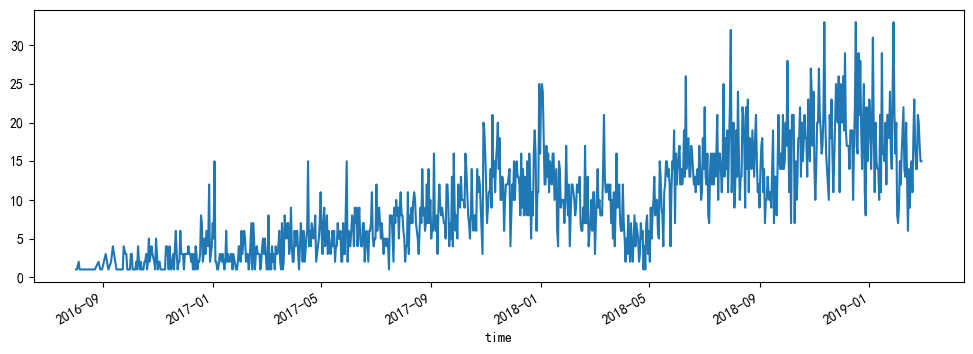

In [48]:
df['time'] = pd.to_datetime(df['time'],format='%Y/%m/%d')
df.groupby(by='time')['rating'].count().plot(figsize=(12,4))
# 整体趋势：上升
# 18年5月前后出现大波动，需结合具体原因分析，可能是因为恶劣天气原因或疫情

#### a2每月销量分析

Text(0.5, 1.0, '16~19年每月销售数量')

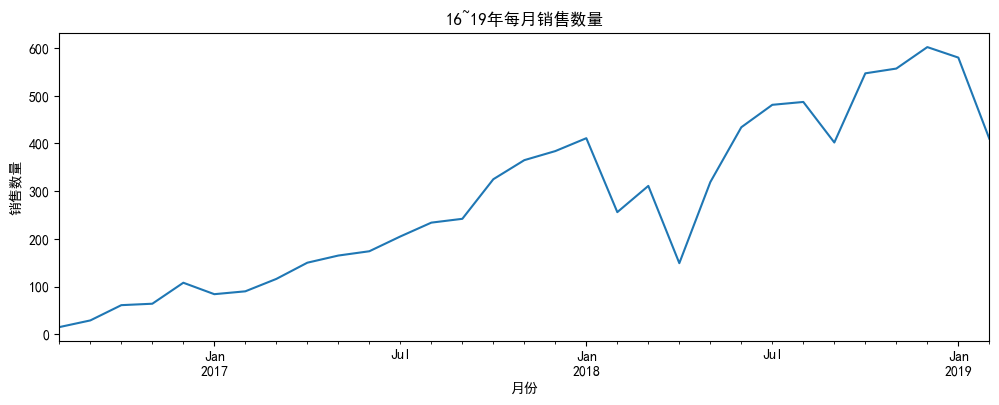

In [49]:
df['month'] = df['time'].dt.to_period('M')
df.groupby('month')['rating'].count().plot(figsize=(12,4))
plt.xlabel('月份')
plt.ylabel('销售数量')
plt.title('16~19年每月销售数量')

#### a3每个用户的购买量和消费金额分析

Text(0, 0.5, '消费金额')

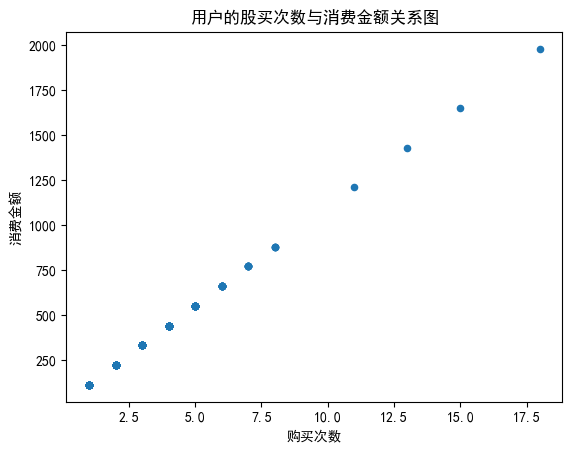

In [50]:
grouped_sum_author = df.groupby('author')['frequency'].sum().reset_index()  # 统计每个游客的购买次数
grouped_sum_amount = df.groupby('author')['amount'].sum().reset_index()  # 统计每个游客的消费金额
user_purchase_retention = pd.merge(left=grouped_sum_author,
                                   right=grouped_sum_amount,
                                   on='author',
                                   how='inner')
user_purchase_retention.plot.scatter(x='frequency', y='amount')
plt.title('用户的股买次数与消费金额关系图')
plt.xlabel('购买次数')
plt.ylabel('消费金额')

#### b1用户购买门票数量分析

Text(0.5, 1.0, '用户购买门票数量直方图')

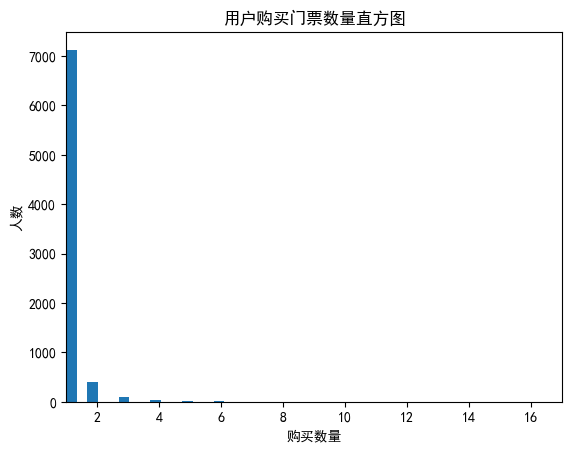

In [51]:
df.groupby('author')['frequency'].count().plot.hist(bins=50)
plt.xlim(1,17)
plt.xlabel('购买数量')
plt.ylabel('人数')
plt.title('用户购买门票数量直方图')
# 绝大多数用户购买过1张门票，用户在7000人以上
# 少数人购买过2~4张门票，可能是附近居民

#### b2用户多次购买情况分析

Text(0.5, 1.0, '多次购买的用户数量')

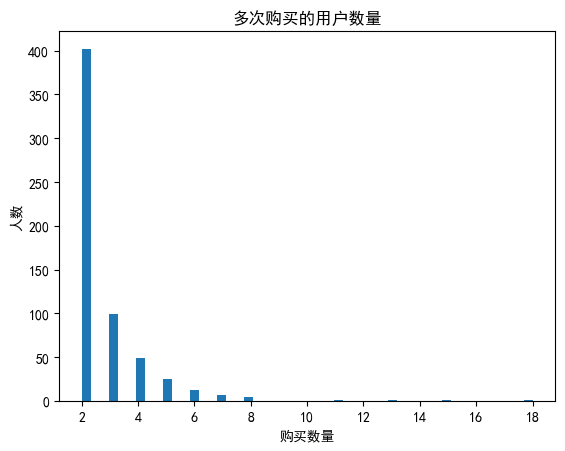

In [52]:
df_frequency_2 = df.groupby('author').count().reset_index()
df_frequency_2[df_frequency_2['frequency']>=2].groupby('author')['frequency'].sum().plot.hist(bins=50)
plt.xlabel('购买数量')
plt.ylabel('人数')
plt.title('多次购买的用户数量')

In [53]:
df_frequency_2[df_frequency_2['frequency']>=2].groupby('frequency')['author'].count()
# 购买次数在2~5的占了80%

frequency
2     402
3      99
4      49
5      25
6      13
7       7
8       4
11      1
13      1
15      1
18      1
Name: author, dtype: int64

#### b3购买次数在1~5次之间的用户占比

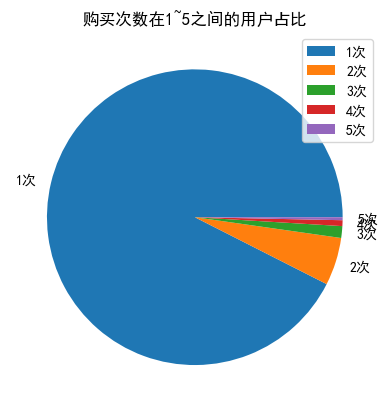

In [54]:
df_frequency_gte_1 = df.groupby('author')['frequency'].count().reset_index()  # 购买次数>=1
values = df_frequency_gte_1[df_frequency_gte_1['frequency']<=5]  # 购买次数<=5
values = list(values.groupby('frequency')['frequency'].count())
labels = ['1次','2次','3次','4次','5次']
plt.pie(values,labels=labels)
plt.title('购买次数在1~5之间的用户占比')
plt.legend()

#### b4购买次数在2~5次之间的用户占比

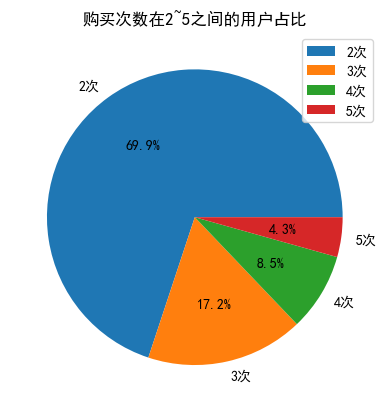

In [55]:
df_frequency_gte_1 = df.groupby('author')['frequency'].count().reset_index()
values = df_frequency_gte_1[df_frequency_gte_1['frequency']>=2]  # 购买次数>=2
values_2 = values[values['frequency']<=5]  # 购买次数<=5
values_2 = list(values_2.groupby('frequency')['frequency'].count())
labels = ['2次','3次','4次','5次']
plt.pie(values_2,labels=labels,autopct='%.1f%%')
plt.title('购买次数在2~5之间的用户占比')
plt.legend()

#### c1复购率分析

C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\2029094362.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_count = pivot_count.applymap(lambda x: 1 if x>1 else np.NaN if x==0 else 0)


Text(0.5, 1.0, '16~19年每月用户复购率')

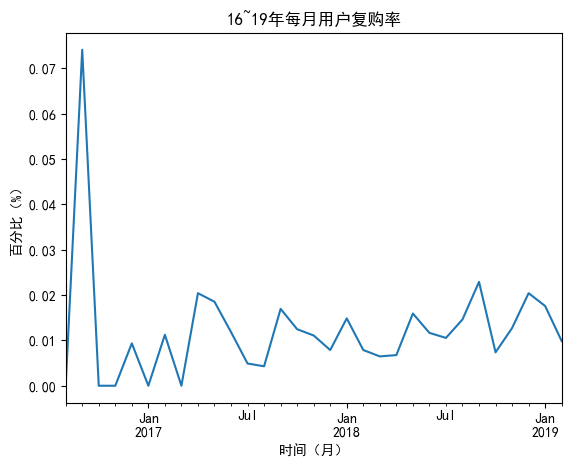

In [56]:
pivot_count = df.pivot_table(index='author',
                             columns='month',
                             values='frequency',
                             aggfunc='count').fillna(0)
# 消费次数>1，为复购用户，用1表示
# 消费次数=1，为非复购用户，用0表示
# 消费次数=0，为未消费用户，用NaN表示
pivot_count = pivot_count.applymap(lambda x: 1 if x>1 else np.NaN if x==0 else 0)
(pivot_count.sum()/pivot_count.count()).plot()
plt.xlabel('时间（月）')
plt.ylabel('百分比（%）')
plt.title('16~19年每月用户复购率')

#### c2用户复购人数

Text(0.5, 1.0, '16~19年每月用户复购人数折线图')

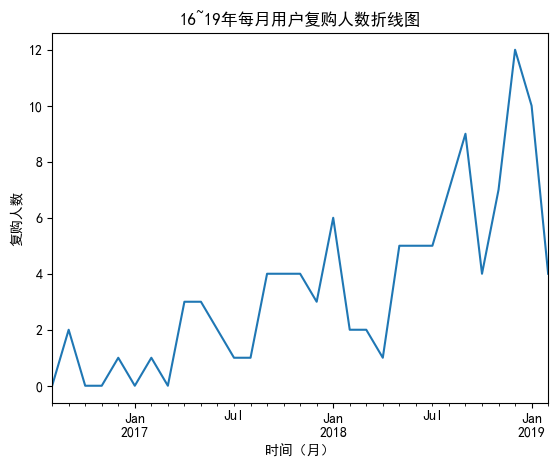

In [57]:
pivot_count.sum().plot()
plt.xlabel('时间（月）')
plt.ylabel('复购人数')
plt.title('16~19年每月用户复购人数折线图')

#### c3回购率分析

In [58]:
pivot_purchase = df.pivot_table(index='author',
                             columns='month',
                             values='frequency',
                             aggfunc='count').fillna(0)
len(pivot_purchase.columns)

31

C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\2067131858.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i]==1:
C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\2067131858.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i+1]==1:


Text(0.5, 1.0, '16年~19年每月的回购率')

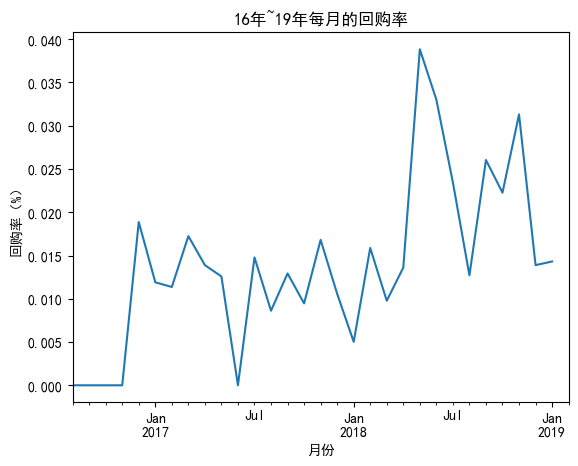

In [64]:
def purchase_return(data):
    status = []
    for i in range(30):
        if data[i]==1:
            if data[i+1]==1:
                status.append(1)
            else:
                status.append(0)
        else:
            status.append(np.NaN)
    status.append(np.NaN)
    return pd.Series(status,pivot_purchase.columns)
pivot_purchase_return = pivot_purchase.apply(purchase_return,axis=1)
(pivot_purchase_return.sum()/pivot_purchase_return.count()).plot()
plt.xlabel('月份')
plt.ylabel('回购率（%）')
plt.title('16年~19年每月的回购率')

#### c4回购人数分析

Text(0.5, 1.0, '16年~19年每月的回购人数')

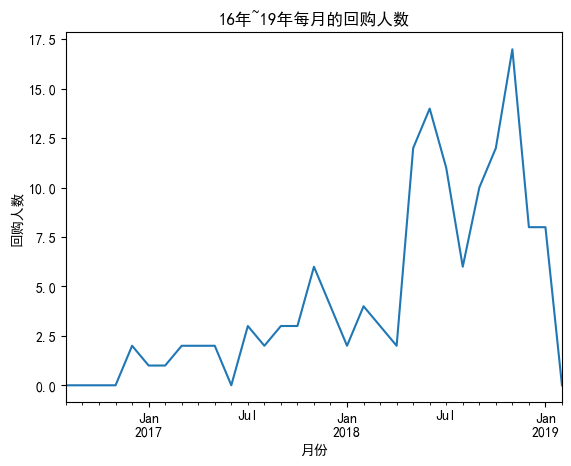

In [65]:
pivot_purchase_return.sum().plot()
plt.xlabel('月份')
plt.ylabel('回购人数')
plt.title('16年~19年每月的回购人数')

#### c5每个月的分层用户占比情况

C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\1872854788.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i] == 0:
C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\1872854788.py:25: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pivot_status_count = pivot_purchase_states.replace('unreg',np.NaN).apply(pd.value_counts)
C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\1872854788.py:25: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pivot_status_count = pivot_purchase_states.replace('unreg',np.NaN).apply(pd.value_counts)
C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\1872854788.py:25: FutureWarning: pandas.value_

<Axes: xlabel='month'>

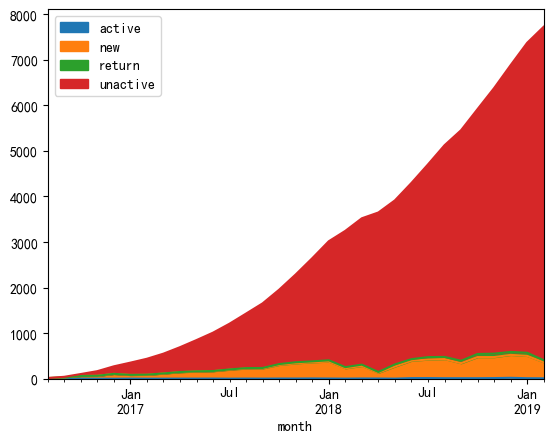

In [69]:
# 活跃用户|不活跃用户|回流用户|新用户
def active_status(data):
    status = []  # 存储18个月的状态：unreg/new/active/unactive/return
    for i in range(31):
        if data[i] == 0:
            if len(status) == 0:
                status.append('unreg')
            else:
                if status[i-1] == 'unreg':
                    status.append('unreg')
                else:
                    status.append('unactive')
        else:
            if len(status) == 0:
                status.append('new')
            else:
                if status[i-1] == 'unactive':
                    status.append('return')
                elif status[i-1] == 'unreg':
                    status.append('new')
                else:
                    status.append('active')
    return pd.Series(status,pivot_purchase.columns)
pivot_purchase_states = pivot_purchase.apply(active_status,axis=1)
pivot_status_count = pivot_purchase_states.replace('unreg',np.NaN).apply(pd.value_counts)
pivot_status_count.T.plot.area()


#### c6每月不同用户的占比

<Axes: xlabel='month'>

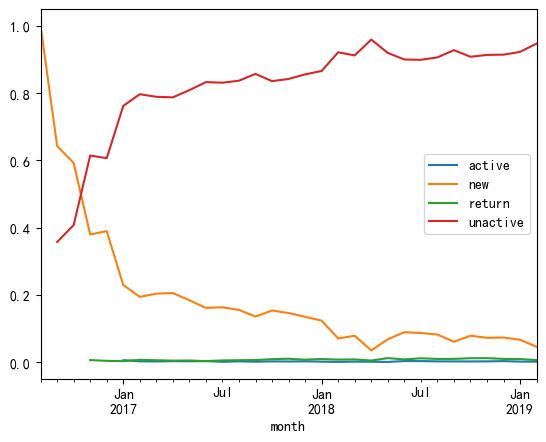

In [72]:
return_rate = pivot_status_count.apply(lambda x: x/x.sum())
return_rate.T.plot()

#### c7每月活跃用户占比

Text(0.5, 1.0, '每月活跃用户占比分析')

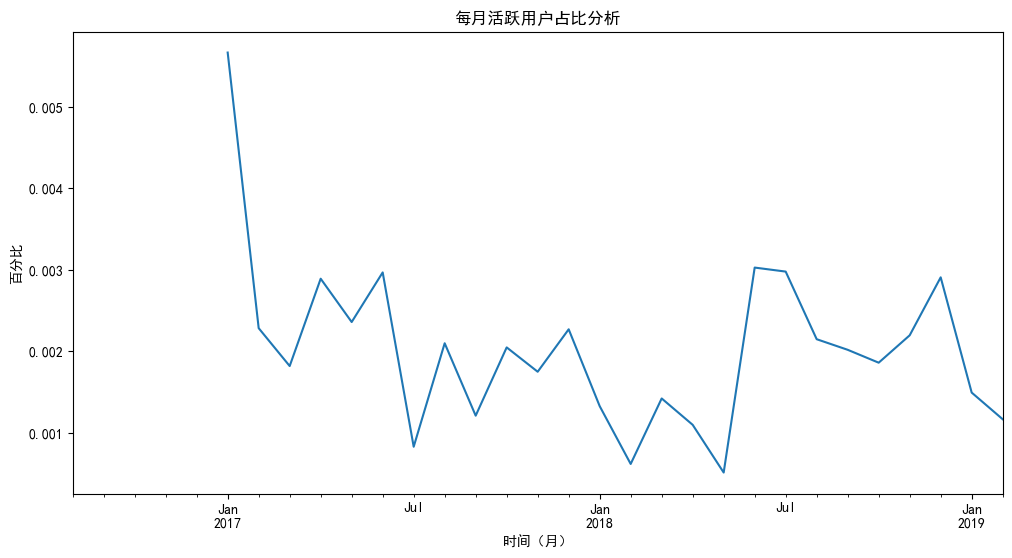

In [79]:
# 活跃用户与回流用户不够直观，单独观察
return_rate.T['active'].plot(figsize=(12,6))
plt.xlabel('时间（月）')
plt.ylabel('百分比')
plt.title('每月活跃用户占比分析')
# 每年1~2月活跃用户急剧下降，可能与春节有关
# 每年2~5月出现异常，可能与雨水或气温有关

#### c8每月回流用户占比

Text(0.5, 1.0, '每月回流用户占比分析')

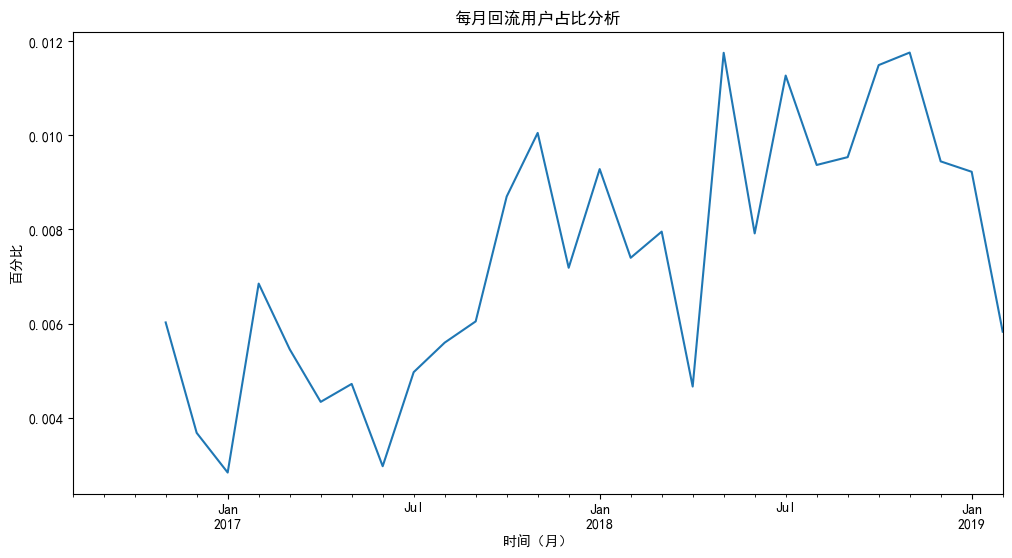

In [80]:
return_rate.T['return'].plot(figsize=(12,6))
plt.xlabel('时间（月）')
plt.ylabel('百分比')
plt.title('每月回流用户占比分析')
# 整体呈上升趋势
# 每年1月左右回流用户比例都会出现大幅度下降

In [81]:
np.mean(return_rate.T['return'])
# 在17年9月份后，仅有两个异常点在平均值之下
# 在17年9月份前，所有数据均低于平均值，可能与景点处于开放初期有关

0.00736823576229978

#### d1用户的生命周期

In [93]:
time_min = df.groupby('author')['time'].min()
time_max = df.groupby('author')['time'].max()
life_time = (time_max-time_min).reset_index()
life_time.describe()
# 通过原样本8757条和count7722条可以得出，存在一个用户多次消费的情况

,time
count,7722
mean,23 days 01:45:32.867132867
std,98 days 16:47:46.849668504
min,0 days 00:00:00
25%,0 days 00:00:00
50%,0 days 00:00:00
75%,0 days 00:00:00
max,864 days 00:00:00


#### d2用户生命周期直方图

Text(0.5, 1.0, '所有用户的生命周期直方图')

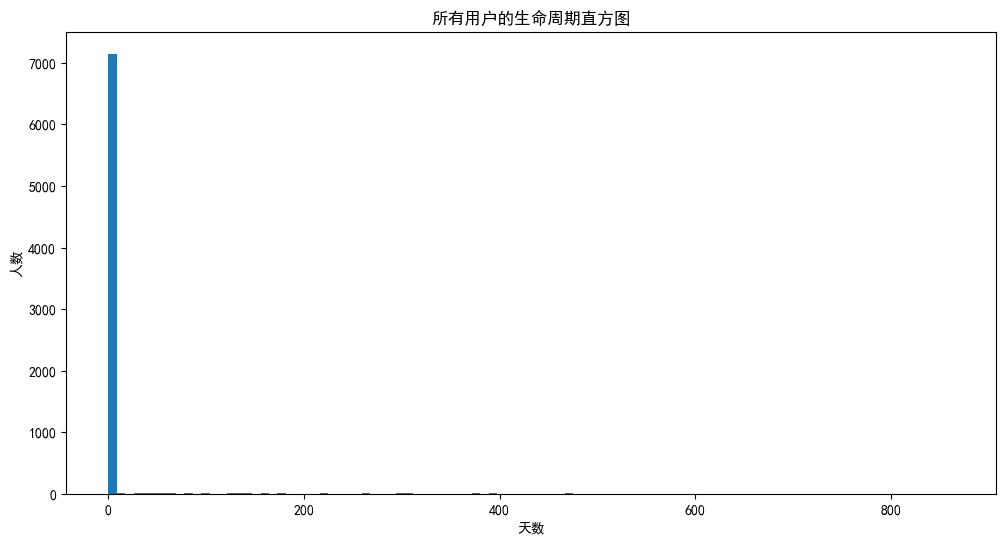

In [95]:
# 将日期类型转换成数值类型
life_time['life_time'] = life_time['time']/np.timedelta64(1,'D')
life_time['life_time'].plot.hist(bins=100,figsize=(12,6))
plt.xlabel('天数')
plt.ylabel('人数')
plt.title('所有用户的生命周期直方图')

#### d3生命周期大于0天的用户直方图

300.9662162162162

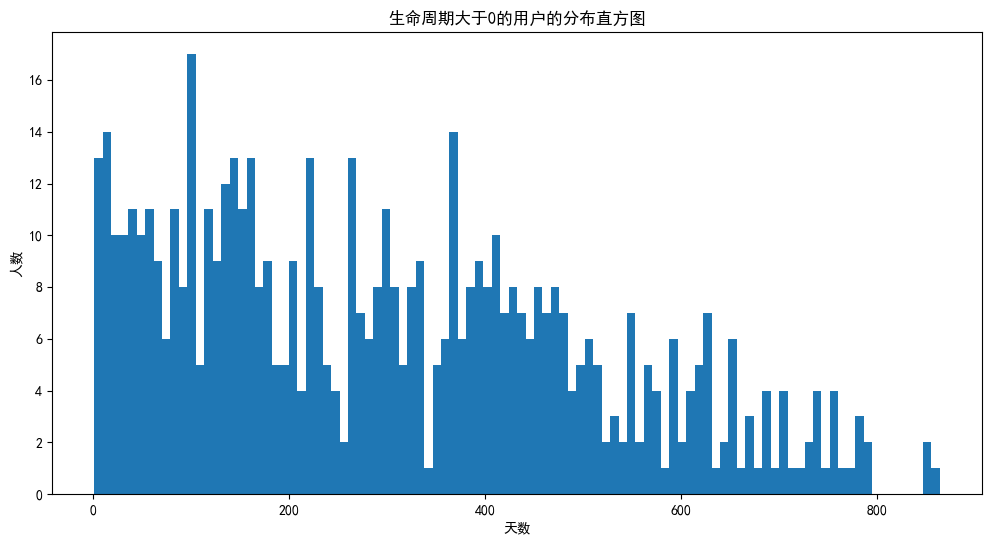

In [99]:
life_time[life_time['life_time']>0]['life_time'].plot.hist(bins=100,figsize=(12,6))
plt.xlabel('天数')
plt.ylabel('人数')
plt.title('生命周期大于0的用户的分布直方图')
life_time[life_time['life_time']>0]['life_time'].mean()

#### d4各时间段的用户留存率

C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\4039495235.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_retention = user_purchase_retention.groupby(['author','time_diff_bin'])['frequency'].sum().unstack()
C:\Users\GJ921\AppData\Local\Temp\ipykernel_45420\4039495235.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_retention_trans = pivot_retention.applymap(lambda x:1 if x>0 else 0)


time_diff_bin
(0, 90]       0.022663
(90, 180]     0.019814
(180, 270]    0.016058
(270, 360]    0.014893
(360, 450]    0.014375
(450, 540]    0.009842
(540, 630]    0.007641
(630, 720]    0.004921
(720, 810]    0.002720
(810, 900]    0.000389
dtype: float64


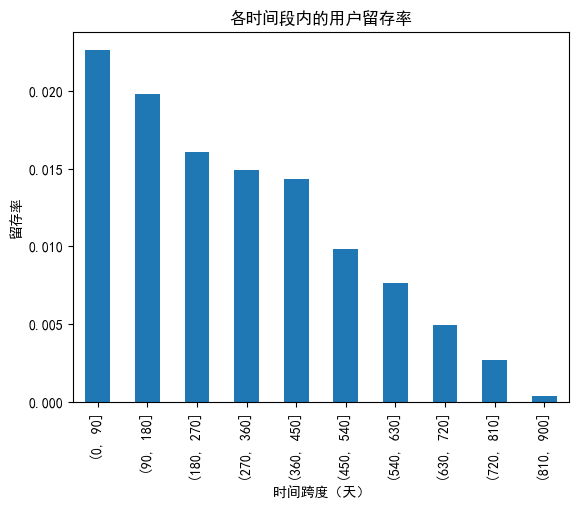

In [118]:
user_purchase_retention = pd.merge(left=df,right=time_min.reset_index(),how='inner',on='author',suffixes=('','_min'))
user_purchase_retention['time_diff'] = user_purchase_retention['time']-user_purchase_retention['time_min']  # 计算留存天数
user_purchase_retention['time_diff'] = user_purchase_retention['time_diff'].apply(lambda x:x/np.timedelta64(1,'D'))

#生成时间跨度，判断归属区间
bin = [i*90 for i in range(11)]
user_purchase_retention['time_diff_bin'] = pd.cut(user_purchase_retention['time_diff'],bin)

# 统计每个游客在不同时间段内的消费频率和值
pivot_retention = user_purchase_retention.groupby(['author','time_diff_bin'])['frequency'].sum().unstack()

#判断是否是留存用户（1：留存，0：未留存）
pivot_retention_trans = pivot_retention.applymap(lambda x:1 if x>0 else 0)

# 留存率
(pivot_retention_trans.sum()/pivot_retention_trans.count()).plot.bar()
plt.xlabel('时间跨度（天）')
plt.ylabel('留存率')
plt.title('各时间段内的用户留存率')
print(pivot_retention_trans.sum()/pivot_retention_trans.count())
# 由图可知：每个周期是三个月，前三个周期递减速度在0.3%左右
# 第四五个周期稳定在1.5%左右
# 后面又开始明显下降，下降到几乎0%，应该在第四五周期（1年）的时候采取方式挽留用户，否则将面临用户大量流失的风险